In [343]:
import numpy as np
import mne
from pathlib import Path
import pandas as pd
from scipy.stats import zscore
import mne
from mne.preprocessing import ICA

from mne_icalabel import label_components
import numpy as np
from scipy.signal import stft
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import stft
import matplotlib.pyplot as plt

In [344]:
CANE_DIR = Path("../CANE/")
MDD_DIR = Path("../MDD/")

In [345]:
raw = mne.io.read_raw_edf(MDD_DIR / 'MDD S1 EC.edf', preload=True)
print(raw.info)
raw

Extracting EDF parameters from /home/milan/Documents/diplomka/MDD/MDD S1 EC.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 77567  =      0.000 ...   302.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1-LE, EEG F3-LE, EEG C3-LE, EEG P3-LE, EEG O1-LE, EEG ...
 chs: 20 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 80.0 Hz
 meas_date: 2013-06-06 16:44:47 UTC
 nchan: 20
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Ab_Ibrahim_W0, sex: 1, last_name: XX, birthday: 2001-01-01>
>


<RawEDF | MDD S1 EC.edf, 20 x 77568 (303.0 s), ~11.9 MiB, data loaded>

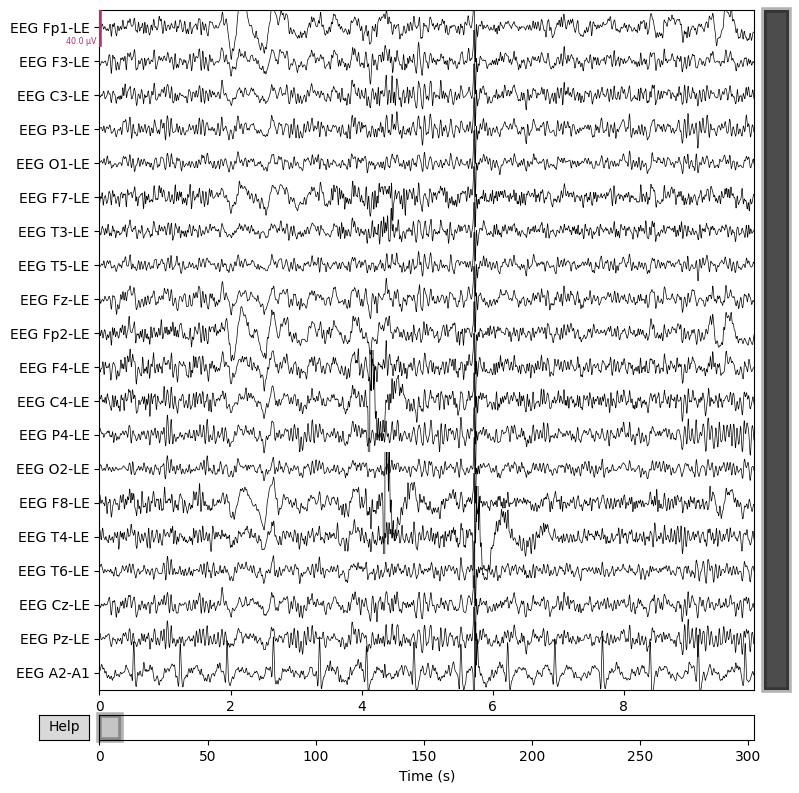

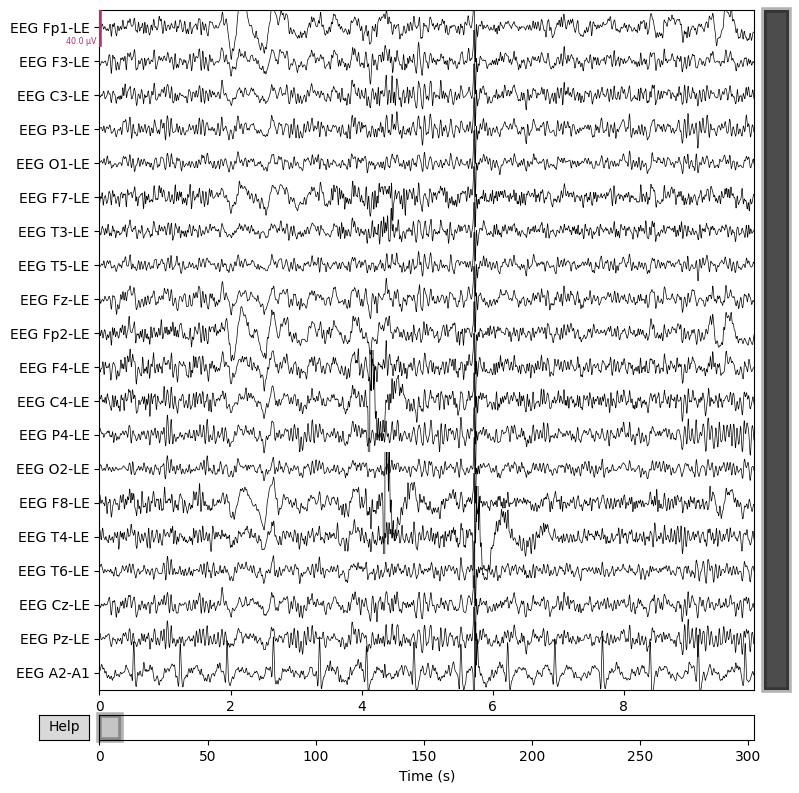

In [346]:
raw.plot()

## Preprocessing MDD dataset

In [347]:
# https://en.wikipedia.org/wiki/Butterworth_filter
# ICA is sensitive to low-frequency drifts and therefore requires the data to be high-pass filtered prior to fitting. Typically, a cutoff frequency of 1 Hz is recommended.
# ^ from ICA docs: https://mne.tools/stable/generated/mne.preprocessing.ICA.html#mne.preprocessing.ICA
raw = raw.filter(l_freq=1, h_freq=70, method="iir")
raw = raw.notch_filter(freqs=50)

# TODO not sure about Cz; Add T7, T8 - ma to nejake ackove, chceckni ten clanek
raw = raw.pick(["EEG Fp1-LE", "EEG Fp2-LE", "EEG C3-LE",  "EEG C4-LE", "EEG O2-LE", "EEG Cz-LE"])
mapping = {
    "EEG Fp1-LE": "Fp1",
    "EEG Fp2-LE": "Fp2",
    "EEG C3-LE": "C3",
    "EEG C4-LE": "C4",
    "EEG O2-LE": "O2",
    "EEG Cz-LE": "Cz"
}
raw = raw.rename_channels(mapping)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 70 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 70.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)



In [348]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, C3, C4, O2, Cz
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 1.0 Hz
 lowpass: 70.0 Hz
 meas_date: 2013-06-06 16:44:47 UTC
 nchan: 6
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Ab_Ibrahim_W0, sex: 1, last_name: XX, birthday: 2001-01-01>
>

In [349]:
# remember, we’re applying the ICA solution from the filtered data to the original unfiltered signal. Why?? read it properly
# https://mne.tools/mne-icalabel/0.4/generated/examples/00_iclabel_automatic_artifact_correction_ica.html

# TODO: maybe use autoreject library instead
filt_raw = raw.set_eeg_reference("average")
ica = ICA(
    max_iter="auto",
    method="infomax",
    random_state=97, # seed?
    fit_params=dict(extended=True),
)
ica.fit(filt_raw)
ica

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 6 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 5 components
Computing Extended Infomax ICA
Fitting ICA took 7.8s.


Method,infomax
Fit parameters,extended=Truemax_iter=500
Fit,500 iterations on raw data (77568 samples)
ICA components,5
Available PCA components,6
Channel types,eeg
ICA components marked for exclusion,—


In [350]:
montage = mne.channels.make_standard_montage("standard_1020")
montage
# 2. Apply montage (MNE will keep only those channels that exist in raw)
filt_raw = filt_raw.set_montage(montage, match_case=False)
ic_labels = label_components(filt_raw, ica, method="iclabel")


/tmp/ipykernel_51325/221652538.py:5: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(filt_raw, ica, method="iclabel")


In [351]:
labels = ic_labels["labels"]
print(labels)
exclude_idx = [idx for idx, label in enumerate(labels) if label not in ["brain", "other"]]
print(f"Excluding these ICA components: {exclude_idx}")
# ica.apply() changes the Raw object in-place, so let's make a copy first:
preprocessed = filt_raw.copy()
ica.apply(preprocessed, exclude=exclude_idx)

['brain', 'brain', 'brain', 'brain', 'eye blink']
Excluding these ICA components: [4]
Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 1 ICA component
    Projecting back using 6 PCA components


<RawEDF | MDD S1 EC.edf, 6 x 77568 (303.0 s), ~3.6 MiB, data loaded>

Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 0 ICA components
    Projecting back using 6 PCA components


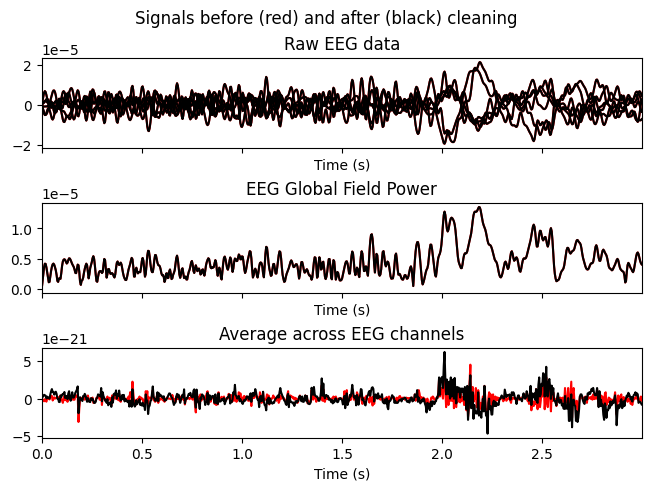

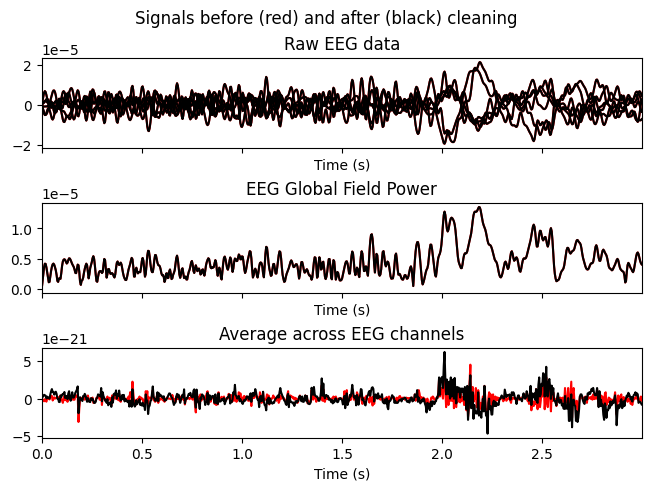

In [352]:
ica.plot_overlay(filt_raw)

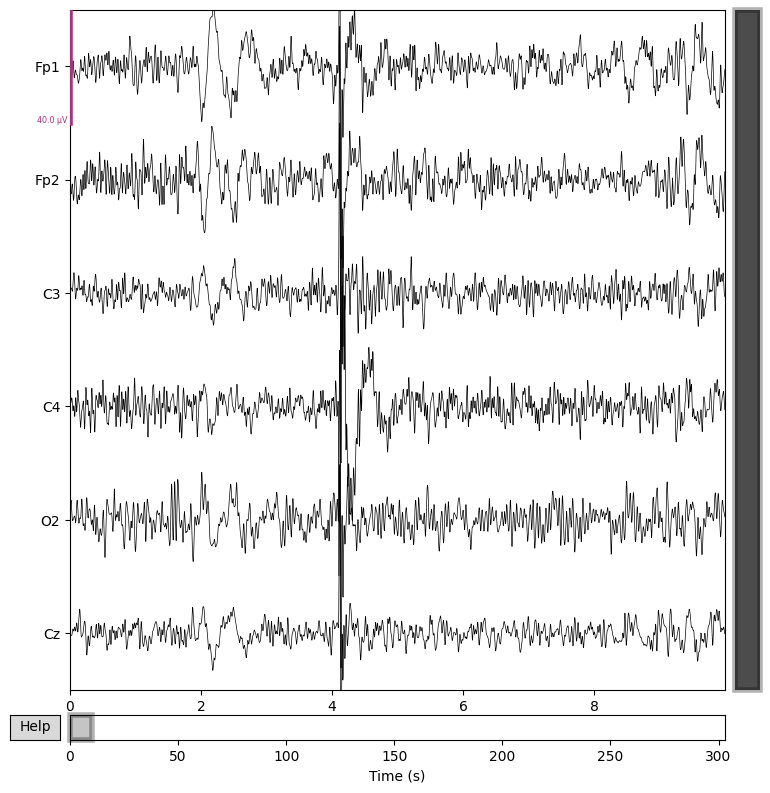

In [353]:
_ = filt_raw.plot()

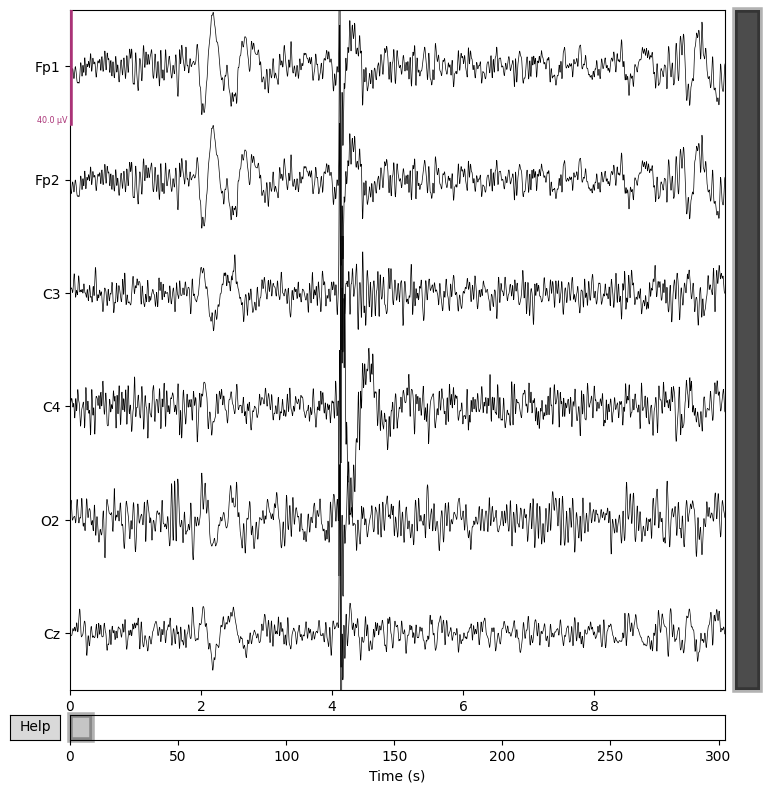

In [354]:
_ = preprocessed.plot()

In [355]:
SEGMENT_LENGTH = 10
SFREQ = 1000 / 4
CHUNK_SAMPLES = int(SEGMENT_LENGTH * SFREQ)

df = preprocessed.to_data_frame()
df

,time,Fp1,Fp2,C3,C4,O2,Cz
0,0.000000,0.021768,0.020920,0.024269,-0.022201,-0.047920,0.003164
1,0.003906,-1.361814,-1.368493,0.586706,0.494326,2.123809,-0.474533
2,0.007812,-2.780180,-2.792508,1.112385,0.864373,4.348426,-0.752496
3,0.011719,-4.062679,-4.079898,1.524322,1.238974,6.190800,-0.811519
4,0.015625,-4.878949,-4.899495,1.776015,1.785213,6.995631,-0.778415
...,...,...,...,...,...,...,...
77563,302.980469,-0.509295,-0.531010,4.629638,0.996757,-9.265093,4.679004
77564,302.984375,-1.668174,-1.691613,4.275679,1.625323,-7.323013,4.781798
77565,302.988281,-1.962546,-1.982718,3.311376,1.630763,-4.786802,3.789927
77566,302.992188,-1.312469,-1.324556,1.819727,1.021085,-2.239010,2.035223


In [356]:
df.describe()

,time,Fp1,Fp2,C3,C4,O2,Cz
count,77568.000000,77568.000000,77568.000000,77568.000000,77568.000000,77568.000000,77568.000000
mean,151.498047,0.000018,-0.000807,0.002012,-0.001297,0.000087,-0.000013
std,87.469130,22.935240,22.920530,22.885531,29.581057,23.593252,21.921867
min,0.000000,-1058.537500,-1057.654095,-1062.217041,-1196.654417,-909.533920,-894.431639
25%,75.749023,-2.537061,-2.549459,-2.288976,-2.482368,-3.575988,-2.113859
50%,151.498047,-0.026113,-0.027052,0.007021,0.016049,0.005312,-0.001047
75%,227.247070,2.563810,2.573305,2.326909,2.479012,3.631031,2.120178
max,302.996094,964.178162,963.406802,961.823549,1179.819321,1025.116478,1010.949360


In [357]:
chunks = [df.iloc[i:i + CHUNK_SAMPLES] for i in range(0, len(df), CHUNK_SAMPLES)]
print(len(chunks))
chunks[0].shape

32


(2500, 7)

In [358]:

# test = pd.DataFrame([[1,5,10], [4,5,6]])
# print(test)
# print(zscore(test, axis=0))

for chunk in chunks:
    # print(chunk)
    norm = pd.DataFrame(zscore(chunk, axis=0)) # hope this is correct axis
    print(norm)
    break

# TODO each segment before sending into classifier -> Z-score
# norm = zscore(raw) # TODO Make sure this is in the proper axis
# norm


          time       Fp1       Fp2        C3        C4        O2        Cz
0    -1.731358 -0.000383 -0.000405  0.005954  0.000704 -0.010071  0.004472
1    -1.729972 -0.239183 -0.239299  0.120135  0.031451  0.374103 -0.100554
2    -1.728587 -0.483986 -0.484144  0.226854  0.053478  0.767632 -0.161666
3    -1.727201 -0.705339 -0.705497  0.310482  0.075776  1.093544 -0.174643
4    -1.725816 -0.846223 -0.846417  0.361578  0.108291  1.235917 -0.167365
...        ...       ...       ...       ...       ...       ...       ...
2495  1.725816 -0.747929 -0.749466  0.822806 -0.065657  0.539180  0.592376
2496  1.727201 -0.686709 -0.687124  0.474442 -0.075033  0.719663  0.622263
2497  1.728587 -0.638782 -0.638579  0.275471 -0.079820  0.779200  0.658308
2498  1.729972 -0.658719 -0.658545  0.275481 -0.055344  0.701414  0.715498
2499  1.731358 -0.773137 -0.773414  0.405849  0.019406  0.527586  0.806895

[2500 rows x 7 columns]


In [359]:
channel = chunk["Fp1"]

In [360]:
print(channel)

0       0.021768
1      -1.361814
2      -2.780180
3      -4.062679
4      -4.878949
          ...   
2495   -4.309444
2496   -3.954737
2497   -3.677059
2498   -3.792571
2499   -4.455498
Name: Fp1, Length: 2500, dtype: float64


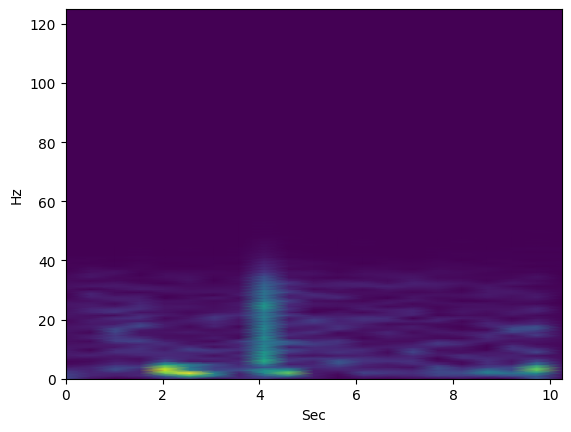

In [361]:
f, t, Zxx = stft(channel, fs=SFREQ, nperseg=256)

plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.ylabel('Hz')
plt.xlabel('Sec')
plt.show()

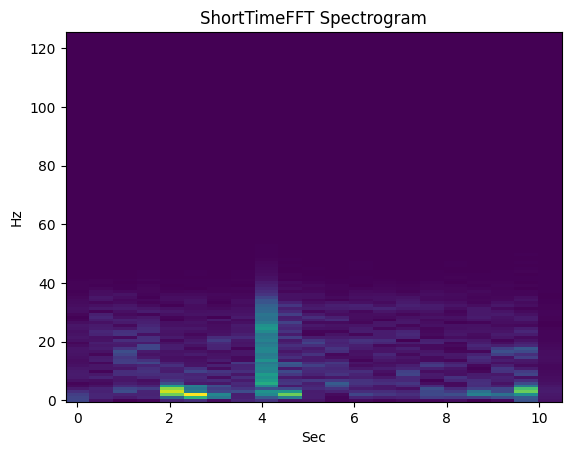

[[-1.00567167e+00+0.00000000e+00j  2.36628577e-01+0.00000000e+00j
   2.39972731e-03+0.00000000e+00j ... -1.00341231e-01+0.00000000e+00j
   1.23763702e+00+0.00000000e+00j  2.41045979e-01+0.00000000e+00j]
 [-8.51629118e-01+5.07308055e-01j  5.04578949e-01+1.01601220e-01j
  -6.82987785e-02-3.43337866e-01j ... -8.68185622e-01+7.86371768e-01j
   6.03522460e-01-1.20426968e+00j -2.24336824e-01+1.50354083e-01j]
 [-3.56492122e-01+8.08994220e-01j  4.83536186e-01+1.36629619e-01j
  -4.94294073e-01-2.89943739e-02j ... -1.66984668e+00+7.20854253e-01j
  -1.08624277e+00-2.18987998e+00j  5.65621881e-02-3.16450065e-01j]
 ...
 [ 2.74582300e-03-2.06868093e-06j  3.04745713e-07+1.43451720e-09j
  -1.09625485e-07-2.13219256e-08j ...  1.55979950e-07-8.09467511e-08j
  -8.54331812e-03-1.45940673e-03j -1.03909102e-02-1.76856332e-03j]
 [ 2.74529531e-03-1.05191742e-06j -3.03484548e-07-7.38554912e-10j
   1.09242297e-07+1.06492480e-08j ... -1.56881076e-07+4.04570560e-08j
  -7.32154516e-04+8.63418889e-03j  8.87198468e-

In [362]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hann  # or another window

# parameters
fs = SFREQ
nperseg = 256
noverlap = nperseg // 2  # e.g., 50% overlap
hop = nperseg - noverlap

# window
win = hann(nperseg, sym=True)

# create transformer
SFT = ShortTimeFFT(win, hop=hop, fs=fs, scale_to='magnitude')  
# Note: scale_to can be 'magnitude', 'psd', or None. :contentReference[oaicite:4]{index=4}

# compute STFT
Sxx = SFT.stft(channel.to_numpy())  # shape: (freq_bins, time_slices) :contentReference[oaicite:5]{index=5}

# get time and frequency axes
f = SFT.f     # frequency values in Hz :contentReference[oaicite:6]{index=6}
t = SFT.t(len(channel))  # times in seconds for each slice

# plot
plt.pcolormesh(t, f, np.abs(Sxx), shading='auto')
plt.ylabel('Hz')
plt.xlabel('Sec')
plt.title('ShortTimeFFT Spectrogram')
plt.show()

print(Sxx)


# CANE dataset

In [363]:
df = pd.read_csv(CANE_DIR / "anxiety/ec/0056_EC.csv")
print(df.shape)
df = df.iloc[::2].reset_index(drop=True)
print(df.shape)

(157744, 13)
(78872, 13)


In [364]:
eeg_channels = ['d1','d2','d3','d4','d5','d6','d7','d8']
df = df[eeg_channels]
df.describe()

,d1,d2,d3,d4,d5,d6,d7,d8
count,78872.000000,78872.000000,78872.000000,78872.000000,78872.000000,78872.000000,78872.000000,78872.000000
mean,-256131.531042,-254247.186060,-250965.035494,158421.201416,-249843.597349,-250933.644559,-252145.425389,-250268.075567
std,223.955434,249.804762,112.588652,20783.773930,198.132963,127.046735,234.013839,194.852640
min,-257589.270000,-255777.255000,-251787.330000,104047.110000,-250730.190000,-252054.720000,-253100.880000,-251248.095000
25%,-256295.891250,-254428.976250,-251037.045000,144549.157500,-249986.970000,-251020.350000,-252310.646250,-250417.305000
50%,-256134.195000,-254243.205000,-250968.870000,162733.680000,-249848.797500,-250944.615000,-252154.665000,-250274.340000
75%,-255968.145000,-254069.280000,-250901.178750,175824.101250,-249724.170000,-250840.395000,-251998.560000,-250135.020000
max,-254647.665000,-252806.940000,-249575.985000,196330.680000,-247960.710000,-249455.160000,-250116.930000,-248354.955000


In [365]:
df_scaled = df - df.mean()
df_scaled = df_scaled / (80_000_000)
df_scaled.describe()

,d1,d2,d3,d4,d5,d6,d7,d8
count,7.887200e+04,7.887200e+04,7.887200e+04,7.887200e+04,7.887200e+04,7.887200e+04,7.887200e+04,7.887200e+04
mean,-3.049051e-19,-2.897511e-19,1.392285e-19,2.252202e-19,-1.915032e-19,-4.029770e-19,3.812908e-19,-5.014119e-19
std,2.799443e-06,3.122560e-06,1.407358e-06,2.597972e-04,2.476662e-06,1.588084e-06,2.925173e-06,2.435658e-06
min,-1.822174e-05,-1.912586e-05,-1.027868e-05,-6.796761e-04,-1.108241e-05,-1.401344e-05,-1.194318e-05,-1.225024e-05
25%,-2.054503e-06,-2.272377e-06,-9.001188e-07,-1.734005e-04,-1.792158e-06,-1.083818e-06,-2.065261e-06,-1.865368e-06
50%,-3.329948e-08,4.976325e-08,-4.793133e-08,5.390598e-05,-6.500189e-08,-1.371305e-07,-1.154951e-07,-7.830542e-08
75%,2.042326e-06,2.223826e-06,7.982093e-07,2.175362e-04,1.492842e-06,1.165619e-06,1.835817e-06,1.663195e-06
max,1.854833e-05,1.800308e-05,1.736313e-05,4.738685e-04,2.353609e-05,1.848106e-05,2.535619e-05,2.391401e-05


In [366]:
# Avoid log(0) by adding a small epsilon
# eps = 1e-9
# df_scaled = np.sign(df) * np.log10(np.abs(df) + eps)
# df_scaled = (df_scaled - df_scaled.mean()) / df_scaled.std()
# df_scaled = df_scaled / 10e4
# df_scaled.describe()

In [367]:
# Extract EEG channels
data = df_scaled.to_numpy()  # shape (n_channels, n_samples)
data.shape

(78872, 8)

In [368]:
transposed = data.T
transposed.shape

(8, 78872)

Creating RawArray with float64 data, n_channels=8, n_times=78872
    Range : 0 ... 78871 =      0.000 ...   315.484 secs
Ready.
Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 :  496 windows


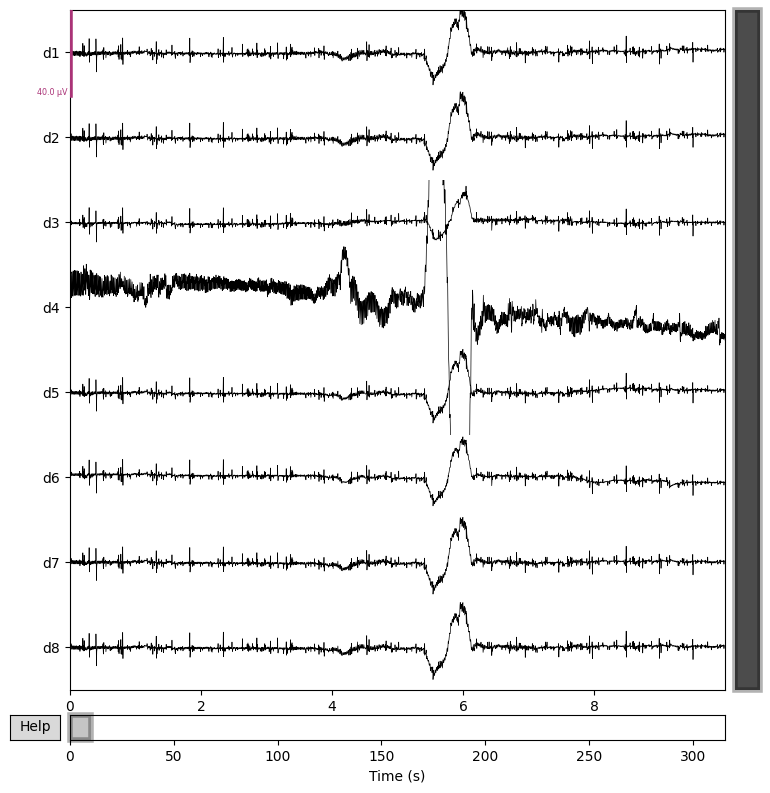

In [369]:
sfreq = 250  # replace with your actual sampling rate
# Create MNE info
info = mne.create_info(ch_names=eeg_channels, sfreq=sfreq, ch_types='eeg')

# Create Raw object
raw = mne.io.RawArray(transposed, info)
raw = raw.notch_filter(freqs=50, picks='eeg', method='spectrum_fit', filter_length='auto', phase='zero')
# print(raw.info)
_ = raw.plot() # scalings="auto"

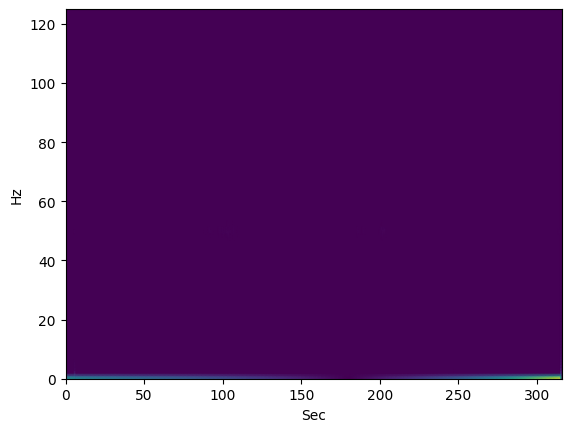

In [370]:


df = raw.to_data_frame()
f, t, Zxx = stft(df["d4"], fs=SFREQ, nperseg=256)

plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.ylabel('Hz')
plt.xlabel('Sec')
plt.show()

In [371]:
norm = zscore(data)
norm

array([[ 0.36178548, -0.03259401,  2.56281138, ...,  3.66933175,
         3.57021269,  4.09048326],
       [-2.90938166, -2.6816016 , -1.32242967, ..., -0.74396481,
         1.07238222,  0.54646979],
       [-2.51494511, -2.377485  ,  0.14222714, ...,  0.26938815,
         1.36322449,  0.96262139],
       ...,
       [ 0.92451504,  1.06396235,  0.07153957, ..., -0.0837488 ,
        -1.54028368, -1.23598285],
       [ 1.74474895,  1.73562934, -0.17610775, ...,  0.50688645,
        -1.02266396, -0.52880825],
       [ 2.45742973,  2.31604023, -0.57514352, ...,  1.20702326,
        -0.46814154,  0.27360187]], shape=(78872, 8))

In [372]:
print(norm.min(axis=0))
print(norm.max(axis=0))

[ -9.71641505  -8.25756736  -7.98470339  -2.59258737  -5.35929759
 -11.84142542  -4.67788292  -7.6490425 ]
[ 9.86594441  7.73828123 14.82934083  1.78501295 12.08811186 16.5959811
 11.22102221 15.05707897]


In [373]:
df = pd.DataFrame([[1,2,3,4,5], [1,3,5,7,9]])
df = df.T
print(df.shape)
print(df)
df = df.iloc[::2].reset_index(drop=True)
df

(5, 2)
   0  1
0  1  1
1  2  3
2  3  5
3  4  7
4  5  9


,0,1
0,1,1
1,3,5
2,5,9
